## About Dataset
### Context:
This dataset contains information about employees in a company, including their educational backgrounds, work history, demographics, and employment-related factors. It has been anonymized to protect privacy while still providing valuable insights into the workforce.

### Columns:

**Education**: The educational qualifications of employees, including degree, institution, and field of study.

**Joining Year**: The year each employee joined the company, indicating their length of service.

**City**: The location or city where each employee is based or works.

**Payment Tier**: Categorization of employees into different salary tiers.

**Age**: The age of each employee, providing demographic insights.

**Gender**: Gender identity of employees, promoting diversity analysis.

**Ever Benched**: Indicates if an employee has ever been temporarily without assigned work.

**Experience in Current Domain**: The number of years of experience employees have in their current field.

**Leave or Not**: a target column

### Link
https://www.kaggle.com/datasets/tawfikelmetwally/employee-dataset/data

## Data preprocessing

In [1]:
# Import Employee dataset
import pandas as pd

df = pd.read_csv('data/Employee.csv')
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [2]:
df.describe()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
count,4653.000000,4653.000000,4653.000000,4653.000000,4653.000000
mean,2015.062970,2.698259,29.393295,2.905652,0.343864
std,1.863377,0.561435,4.826087,1.558240,0.475047
min,2012.000000,1.000000,22.000000,0.000000,0.000000
25%,2013.000000,3.000000,26.000000,2.000000,0.000000
50%,2015.000000,3.000000,28.000000,3.000000,0.000000
75%,2017.000000,3.000000,32.000000,4.000000,1.000000
max,2018.000000,3.000000,41.000000,7.000000,1.000000


In [3]:
df.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [4]:
# For numerical columns, we will perform data normalization
from sklearn.preprocessing import StandardScaler

columns_to_standartize = ['JoiningYear', 'Age', 'ExperienceInCurrentDomain']
df[columns_to_standartize] = StandardScaler().fit_transform(df[columns_to_standartize])
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,1.039638,Bangalore,3,0.954645,Male,No,-1.864901,0
1,Bachelors,-1.107233,Pune,1,-0.288732,Female,No,0.060554,1
2,Bachelors,-0.570515,New Delhi,3,1.783563,Female,No,-0.581264,0
3,Masters,0.502921,Bangalore,3,-0.495961,Male,No,1.344191,1
4,Masters,1.039638,Pune,3,-1.117650,Male,Yes,-0.581264,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,-1.107233,Bangalore,3,-0.703191,Female,No,0.702373,0
4649,Masters,-1.107233,Pune,2,1.576334,Male,No,-0.581264,1
4650,Masters,1.576356,New Delhi,3,-0.495961,Male,No,1.344191,1
4651,Bachelors,-1.643951,Bangalore,3,0.125727,Male,Yes,-0.581264,0


In [5]:
# Transforming categorical features into a set of numerical columns
df = pd.get_dummies(df, columns=['Education', 'Gender', 'PaymentTier', 'City', 'EverBenched'])
df

,JoiningYear,Age,ExperienceInCurrentDomain,LeaveOrNot,Education_Bachelors,Education_Masters,Education_PHD,Gender_Female,Gender_Male,PaymentTier_1,PaymentTier_2,PaymentTier_3,City_Bangalore,City_New Delhi,City_Pune,EverBenched_No,EverBenched_Yes
0,1.039638,0.954645,-1.864901,0,True,False,False,False,True,False,False,True,True,False,False,True,False
1,-1.107233,-0.288732,0.060554,1,True,False,False,True,False,True,False,False,False,False,True,True,False
2,-0.570515,1.783563,-0.581264,0,True,False,False,True,False,False,False,True,False,True,False,True,False
3,0.502921,-0.495961,1.344191,1,False,True,False,False,True,False,False,True,True,False,False,True,False
4,1.039638,-1.117650,-0.581264,1,False,True,False,False,True,False,False,True,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4648,-1.107233,-0.703191,0.702373,0,True,False,False,True,False,False,False,True,True,False,False,True,False
4649,-1.107233,1.576334,-0.581264,1,False,True,False,False,True,False,True,False,False,False,True,True,False
4650,1.576356,-0.495961,1.344191,1,False,True,False,False,True,False,False,True,False,True,False,True,False
4651,-1.643951,0.125727,-0.581264,0,True,False,False,False,True,False,False,True,True,False,False,False,True


## Splitting the sample into training and test

In [7]:
# Split the sample into training and test.
# The training sample is used to train the model, and the test sample is used to test its quality.

from sklearn.model_selection import train_test_split

X, Y = df.drop('LeaveOrNot', axis=1), df['LeaveOrNot']
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, random_state = 42, shuffle = True)

## Model training and quality assessment

In [8]:
# Apply classification algorithms: logistic regression, SVM, KNN.
# Construct a confusion matrix based on the model results (use confusion_matrix from sklearn.metrics).

### Logistic regression

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
model = LogisticRegression(random_state = 42)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
y_predict_logistic = model.predict(x_test)
pd.DataFrame(zip(y_test, y_predict_logistic))

,0,1
0,1,0
1,0,0
2,1,1
3,0,1
4,0,0
...,...,...
926,0,0
927,1,0
928,1,1
929,0,0


In [12]:
from sklearn.metrics import confusion_matrix
import plotly.express as px

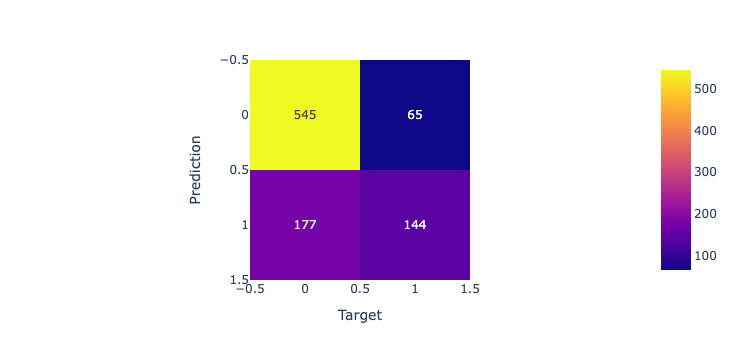

In [13]:
# Build a confusion matrix based on the model's output (use confusion_matrix from sklearn.metrics).

fig = px.imshow(confusion_matrix(y_test, y_predict_logistic), text_auto = True)
fig.update_layout(xaxis_title = 'Target', yaxis_title = 'Prediction')
fig.show()

### Support Vector Machine (SVM)

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [17]:
# find the best kernel for SVM

param_kernel = ('linear', 'rbf', 'poly', 'sigmoid')
parameters = {'kernel': param_kernel}
model = SVC()
grid_search_svm = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid_search_svm.fit(x_train, y_train)

,estimator,SVC()
,param_grid,"{'kernel': ('linear', ...)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1.0


In [18]:
best_model = grid_search_svm.best_estimator_
best_model.kernel

'poly'

In [19]:
y_predict_svm = best_model.predict(x_test)
pd.DataFrame(zip(y_test, y_predict_svm))

,0,1
0,1,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
926,0,0
927,1,0
928,1,1
929,0,0


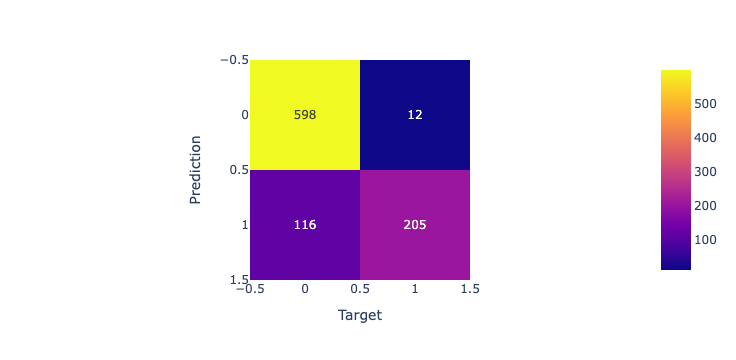

In [20]:
fig = px.imshow(confusion_matrix(y_test, y_predict_svm), text_auto = True)
fig.update_layout(xaxis_title = 'Target', yaxis_title = 'Prediction')
fig.show()

### K-Nearest Neighbors (KNN) Method

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [22]:
# find the best number of neighbours

number_of_neighbors = list(range(2, 11))
model = KNeighborsClassifier()
params = {"n_neighbors": number_of_neighbors}
grid_search = GridSearchCV(estimator=model, param_grid=params, cv=6)
grid_search.fit(x_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [2, 3, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,6
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [23]:
best_model = grid_search.best_estimator_
best_model.kneighbors

<bound method KNeighborsMixin.kneighbors of KNeighborsClassifier(n_neighbors=9)>

In [24]:
y_predict_knn = best_model.predict(x_test)
pd.DataFrame(zip(y_test, y_predict_knn))

,0,1
0,1,0
1,0,0
2,1,0
3,0,0
4,0,0
...,...,...
926,0,0
927,1,0
928,1,1
929,0,0


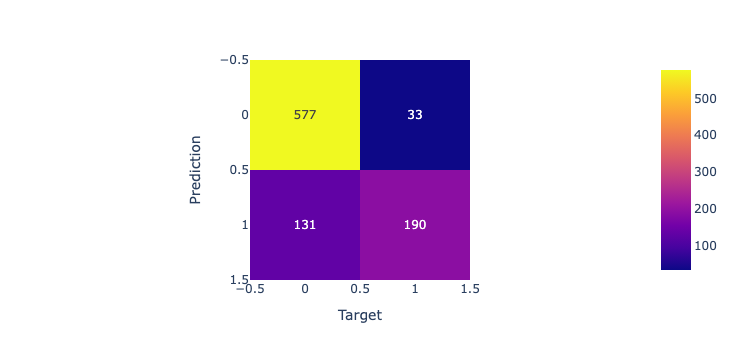

In [25]:
fig = px.imshow(confusion_matrix(y_test, y_predict_knn), text_auto = True)
fig.update_layout(xaxis_title = 'Target', yaxis_title = 'Prediction')
fig.show()

## Comparison of classification results

In [27]:
# Compare classification results using accuracy, precision, recall, and f1-measure

from sklearn.metrics import classification_report

In [28]:
print(classification_report(y_test, y_predict_logistic))

              precision    recall  f1-score   support

           0       0.75      0.89      0.82       610
           1       0.69      0.45      0.54       321

    accuracy                           0.74       931
   macro avg       0.72      0.67      0.68       931
weighted avg       0.73      0.74      0.72       931



In [29]:
print(classification_report(y_test, y_predict_svm))

              precision    recall  f1-score   support

           0       0.84      0.98      0.90       610
           1       0.94      0.64      0.76       321

    accuracy                           0.86       931
   macro avg       0.89      0.81      0.83       931
weighted avg       0.87      0.86      0.85       931



In [30]:
print(classification_report(y_test, y_predict_knn))

              precision    recall  f1-score   support

           0       0.81      0.95      0.88       610
           1       0.85      0.59      0.70       321

    accuracy                           0.82       931
   macro avg       0.83      0.77      0.79       931
weighted avg       0.83      0.82      0.81       931



Conclusions on the classification results:
* The most accurate model was trained using a support vector machine (accuracy=0.86)
* The second most accurate model was trained using a K-nearest neighbors method (accuracy=0.82)
* The least accurate model was logistic regression (accuracy=0.74)